This is the document where one can actually train a classifier (the others scripts bring togethers objects, functions and tests that can be imported in this notebook).

In [147]:
%load_ext line_profiler

## Imports

In [1]:
import src
from src.dataset_reader import download_dataset_from_internet, load_dataset

c:\Users\anato\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Download the dataset

In [ ]:
download_dataset_from_internet()

## Load the dataset into python objects

In [2]:
training_set, test_set = load_dataset(training_size=1000, old_format=True)

In [ ]:
print(training_set[0][0]) # Serait bien aussi de les visualiser. Je vais noter ça comme objectif.
print(training_set[1][0])
print(training_set[2][0]) # Les examples ne semblent pas être triés par label. C'est une bonne chose.

## Instantiation of the multilayer perceptron

In [3]:
import numpy as np

In [4]:
layout = [784, 16, 16, 10] # The images are made of 784 pixels and there're 10 possible results.
multilayer_perceptron = src.script.MultilayerPerceptron(layout=layout, dtype=np.float64)

In [ ]:
print(multilayer_perceptron.variables[2][2])
print(multilayer_perceptron.variables[3][2])
print(multilayer_perceptron.variables[1][0][0][0].dtype)

## Training

In [88]:
previous_costs, previous_accuracies = src.script.learning(multilayer_perceptron= multilayer_perceptron, training_set=training_set, test_set=test_set, steps_number=150, eta = 1e-03)


In [14]:
import matplotlib.pyplot as plt

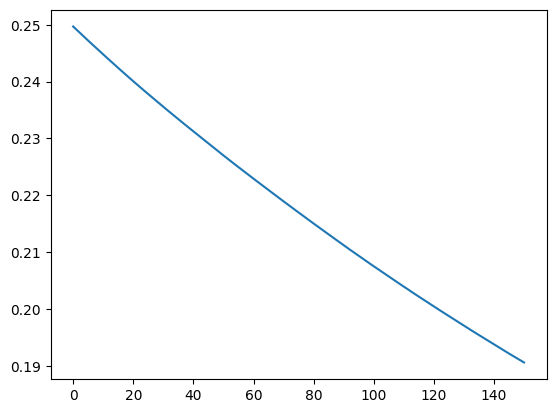

In [89]:
plt.plot(previous_costs)

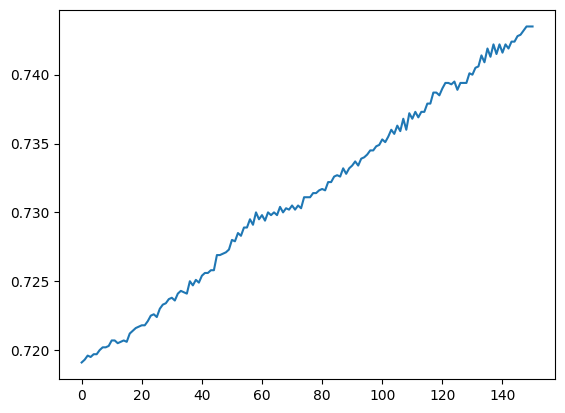

In [90]:
plt.plot(previous_accuracies)

## Testing

8


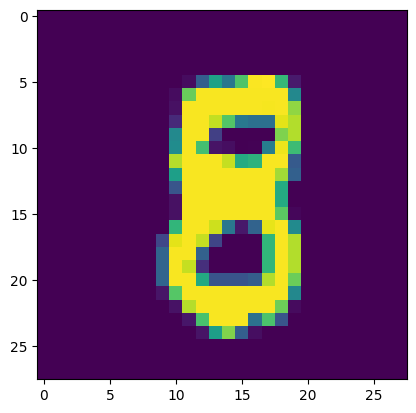

In [145]:
# Select a test image at random
i = np.random.randint(low=0, high=len(test_set))
labeled_example = test_set[i]

# Make the model guess for it
src.script.feed(multilayer_perceptron=multilayer_perceptron, example=labeled_example[1])
guess = np.argmax(multilayer_perceptron.variables[-1][2][0])

# Show the guess and the image
img = labeled_example[1].reshape(28, 28)
plt.imshow(img)
print(guess)

In [125]:
print(src.script.accuracy(multilayer_perceptron=multilayer_perceptron, test_set=test_set))

0.7435


## Profiling

In [148]:
%lprun -f src.script.learning src.script.learning(multilayer_perceptron=multilayer_perceptron, training_set=training_set, test_set=test_set, steps_number=1, eta=1e-03)

Timer unit: 1e-07 s

Total time: 9.24986 s
File: c:\Users\anato\OneDrive\Bureau\Ancien drive cs non connecté 22_05_25\Personnel\Education\Cours\2A\S8\COE 332\my_first_nn\src\script.py
Function: learning at line 553

Line #      Hits         Time  Per Hit   % Time  Line Contents
   553                                           def learning(
   554                                               multilayer_perceptron: MultilayerPerceptron,
   555                                               training_set: list[list[np.array, np.array]],
   556                                               test_set: list[list[np.array, np.array]],
   557                                               stagnation_epsilon: float = 0.1,
   558                                               max_stagnation_steps: int = 3,
   559                                               steps_number=None,
   560                                               eta: float = 1,
   561                                           ):
   

Il semblerait donc, à l'inverse de ce à quoi je m'attendais, que accuracy prenne plus de temps que learning_one_step ! (avec 1000 et non 60000 images ceci dit). Je benchmarkerais bien mtn. Avec timeit.